Script to run inference on our RDM models using partial correlation to exclude control models

In [11]:
#append_str = '_stickfunction'
#append_str = '_stickfunction5'
append_str = '_stickfunction5vis'
#append_str = '_boxcar5vis'


In [12]:

regions = ['Entorhinal-right', 'Entorhinal-left']
#regions = ['rel2Entorhinal-right', 'rel2Entorhinal-left']
models = ['affordance'] 

In [13]:
models

['affordance']

In [20]:
import sys
sys.path.append('/data/u_eperon_software/python/debian-bullseye-amd64/lib/python3.9/site-packages') # in case the environment did not load properly

import os
from glob import glob

import rsatoolbox
import rsatoolbox.data as rsd # abbreviation to deal with dataset
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import nilearn
import nibabel as nib
from nilearn.masking import apply_mask
import rsatoolbox.rdm as rsr
import json
from scipy.stats import spearmanr
import pandas as pd
import scipy
from scipy.stats import ttest_1samp, pearsonr, spearmanr




# =============================================================================
# 2. Set up parameters and paths
# =============================================================================

glm_results_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/nilearn_glm_runwise/'


subs = [os.path.basename(f) for f in glob(glm_results_dir + 'sub*')]
#subs = ["sub-39"]

subs.sort()

sub_ids = [sub[-2:] for sub in subs if '.' not in sub]

# code for subset of subs before vxelrel selection is done
#subs_final = []
#for sub_ in subs:
#    rdm_file = glm_results_dir + f'{sub_}/{sub_}_rel5Entorhinal-bilateral_rdm_crossnobis.pkl'
#    # if file exists load, otherwise continue
#    if os.path.isfile(rdm_file):
#        subs_final.append(sub_)

#subs = subs_final


# load performance dictionary
model_path = '/data/pt_02747/action_hippo/code/extras/'
performance_file = 'subject_performances.json'
with open(os.path.join(model_path, performance_file), 'r') as f:
    performance_dict = json.load(f)

len(subs)



57

In [23]:
# =============================================================================
# function to retrieve neural rdms from a previous analysis
# =============================================================================

def get_neural_rdms(subs_, region_, glm_results_dir=glm_results_dir, append_str=append_str):
    rdms_list = []

    for sub_ in subs_:
        rdm_file = glm_results_dir + f'{sub_}/{sub_}{append_str}_{region_}_rdm_crossnobis.pkl'
        rdm = rsr.load_rdm(rdm_file)
        rdms_list.append(rdm)

    rdms = rsr.concat(rdms_list)

    #print('number of subjects: ', len(subs_))
    #print('number of rdms: ', len(rdms.dissimilarities))

    if rdms.rdm_descriptors['subj'] != subs_:
        print('ERROR: rdms and subjects do not match')
        # stop the code
        raise ValueError('rdms and subjects do not match')
    else:
        #print('rdms and subjects match')
        return rdms

# =============================================================================
# function to get spearman tau correlations between neural and behavioral rdms
# =============================================================================


def compare_rho_a(vector1, vector2):
    """calculates the spearman rank correlations between
    two RDMs objects without tie correction

    Args:
        v1, v2 (numpy.ndarray): RDMs to be compared
    Returns:
        numpy.ndarray: dist:
            rank correlations between the two RDMs

    """

    # check input is np array and if not, make it one
    if type(vector1) is not np.ndarray:
        vector1 = np.array(vector1)
    if type(vector2) is not np.ndarray:
        vector2 = np.array(vector2)

    # check input is 2D and if not, make it one
    if len(vector1.shape) != 2:
        vector1 = np.atleast_2d(vector1)
    if len(vector2.shape) != 2:
        vector2 = np.atleast_2d(vector2)


    # check input is horizontal and if not, make it one
    if vector1.shape[0] > vector1.shape[1]:
        vector1 = vector1.T
    if vector2.shape[0] > vector2.shape[1]:
        vector2 = vector2.T
        
    vector1 = np.apply_along_axis(scipy.stats.rankdata, 1, vector1)
    vector2 = np.apply_along_axis(scipy.stats.rankdata, 1, vector2)
    vector1 = vector1 - np.mean(vector1, 1, keepdims=True)
    vector2 = vector2 - np.mean(vector2, 1, keepdims=True)
    n = vector1.shape[1]
    sim = np.einsum('ij,kj->ik', vector1, vector2) / (n ** 3 - n) * 12
    return sim[0][0]


# =============================================================================
# function to run partial correlation using rho-a
# =============================================================================

def compute_partial_corr(x, y, z_list):
    """
    Compute the partial correlation between x and y, controlling for variables in z_list.
    
    Parameters:
    - x, y: Arrays or lists of the variables for which to calculate the partial correlation.
    - z_list: List of arrays or lists for the control variables.

    Returns:
    - r: The partial correlation coefficient.
    """

    if len(z_list) == 0:
        # No covariates: return the simple Pearson correlation
        return compare_rho_a(x, y)
    
    elif len(z_list) == 1:
        # Partial correlation with one covariate
        z = z_list[0]
        return partial_corr_one(x, y, z)
    
    else:
        # Recursive case: partial correlation with more than one covariate
        z_last = z_list[-1]
        r_xy_z = compute_partial_corr(x, y, z_list[:-1])
        r_xz_last = compute_partial_corr(x, z_last, z_list[:-1])
        r_yz_last = compute_partial_corr(y, z_last, z_list[:-1])
        
        numerator = r_xy_z - r_xz_last * r_yz_last
        denominator = np.sqrt((1 - r_xz_last**2) * (1 - r_yz_last**2))
        # Check for a valid denominator before division
        if denominator == 0:
            return 0
        elif np.isnan(denominator):
            return np.nan
        
        return numerator / denominator

def partial_corr_one(x, y, z):
    """
    Compute the partial correlation between x and y controlling for a single variable z.
    
    Parameters:
    - x, y, z: Arrays or lists of the variables.

    Returns:
    - r: The partial correlation coefficient.
    """

    r_xy = compare_rho_a(x, y)
    r_xz = compare_rho_a(x, z)
    r_yz = compare_rho_a(y, z)

    numerator = r_xy - r_xz * r_yz
    denominator = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    
        
    # Check for a valid denominator before division
    if denominator == 0:
            return 0
    elif np.isnan(denominator):
        return np.nan
    
    return numerator / denominator




# =============================================================================
# function to retrieve  rdms from a previous analysis
# =============================================================================



from rsatoolbox.inference import eval_fixed
from rsatoolbox.inference.evaluate import fisher_transform_results
def get_behav_rdm_correlations_new(subs_, rdms, 
                                    model_name='affordance', 
                                    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/',
                                    models_=['affordance', 'affordance_magnitude', 'link_distance']):
    all_models_corr = [] # correlations between neural and behavioral rdms
    rdms_behav = [] # behavioral rdms
    ind = 0
    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/'

    for sub_ in subs_:

        print('USING PARTIAL CORRELATION')
        print(sub_)
        # get rdm for this subject
        rdm_sub = rdms.subsample('subj', sub_)
        print('sub rdm:', rdm_sub.dissimilarities)
        # get behav_affordance model
        model_file = f"{sub_}_model_dictionaries_rt_test.json"
        with open(model_dir + model_file) as f:
            models = json.load(f)


        model_deets = {}
        for model_ in models_:
            model_diss_tmp = rsatoolbox.rdm.RDMs(np.array([[[models[model_]['11'], models[model_]['12'], models[model_]['13'], models[model_]['14']],
                                                        [models[model_]['12'], models[model_]['22'], models[model_]['23'], models[model_]['24']],
                                                        [models[model_]['13'], models[model_]['23'], models[model_]['33'], models[model_]['34']],
                                                        [models[model_]['14'], models[model_]['24'], models[model_]['34'], models[model_]['44']]]]),
                                    dissimilarity_measure='count',
                                    descriptors={'n_rdm': 1}
                                )
            
            model_deets['model_diss_' + model_] = model_diss_tmp.dissimilarities[0]

        neural_diss_tmp = rdm_sub.dissimilarities[0]

        models_to_exclude = [mod for mod in models_ if mod != model_name]
        # create list from dictionary
        model_diss_exc_tmp = [model_deets['model_diss_' + mod] for mod in models_to_exclude]

        model_diss_inc_tmp = model_deets['model_diss_' + model_name]

        eval_corr = compute_partial_corr(neural_diss_tmp, model_diss_inc_tmp, model_diss_exc_tmp)
        model_diss = model_deets['model_diss_' + model_name]
        
        # if 1 or -1, replace with 0.999 or -0.999
        if eval_corr == 1:
            eval_corr = 0.999
        elif eval_corr == -1:
            eval_corr = -0.999

        eval_score = np.arctanh(eval_corr) # z-score

        rdms_behav.append(model_diss)
        ind += 1
        all_models_corr.append(eval_score)

    return rdms_behav, all_models_corr




In [24]:

# empty list to add data to
data_ = []

for model_ in models:
    for region_ in regions:
        rdms = get_neural_rdms(subs, region_)

        # add find average rdm value for each subject - this way we can see SNR later
        avg_dist = []
        for i in range(len(rdms.dissimilarities)):
            avg_dist.append([np.mean(rdms.dissimilarities[i]), rdms.dissimilarities[i][3]]) #fourth item is 2-3 difference, as rdm reads vertically
            

        rdms_behav, all_models_corr = get_behav_rdm_correlations_new(subs, rdms, model_name=model_)

        
        # add results to dataframe
        for i in range(len(subs)):
            data_.append([subs[i], model_, region_, all_models_corr[i], performance_dict[subs[i]], avg_dist[i][0], avg_dist[i][1]])
        
# make data into dataframe
df = pd.DataFrame(data_, columns=['sub', 'model', 'region', 'correlation', 'performance', 'mean_rdm_value', '32_rdm_value'])

USING PARTIAL CORRELATION
sub-01
sub rdm: [[ 13.33557841   7.52682644  22.51807039  36.60617096  31.42972593
  -20.85867965]]
USING PARTIAL CORRELATION
sub-03
sub rdm: [[  5.39056566  -3.40691904   0.37739721 -54.52505708 -32.48733324
  -42.65594625]]
USING PARTIAL CORRELATION
sub-04
sub rdm: [[ 24.06930826  69.81474282 -19.20398156  62.43644541  -2.68022555
  -43.9879223 ]]
USING PARTIAL CORRELATION
sub-05
sub rdm: [[ 16.30558229 -32.44878873  32.09971637 -11.01649124 124.67402716
  -64.40921255]]
USING PARTIAL CORRELATION
sub-06
sub rdm: [[ 15.74301764   2.07614918 -41.11781644  38.87124675 -25.23795925
  -59.20883485]]
USING PARTIAL CORRELATION
sub-07
sub rdm: [[ 2.29219465 -4.81478994 52.72474235 67.4488383  58.40937187 78.69913038]]
USING PARTIAL CORRELATION
sub-08
sub rdm: [[ -5.1624182  -25.18594552 -21.91520004   8.76084105  76.55825828
   -9.54514501]]
USING PARTIAL CORRELATION
sub-09
sub rdm: [[ 21.00490033  22.72084124  41.34051712  48.65440601  36.85422558
  -23.93902784]]


In [22]:
len(df['sub'].unique())

57

In [8]:
# save data
# df.to_csv(f'/data/pt_02747/action_hippo/figures/rel5rdm_correlations_subs-{len(subs)}{append_str}.csv', index=False)


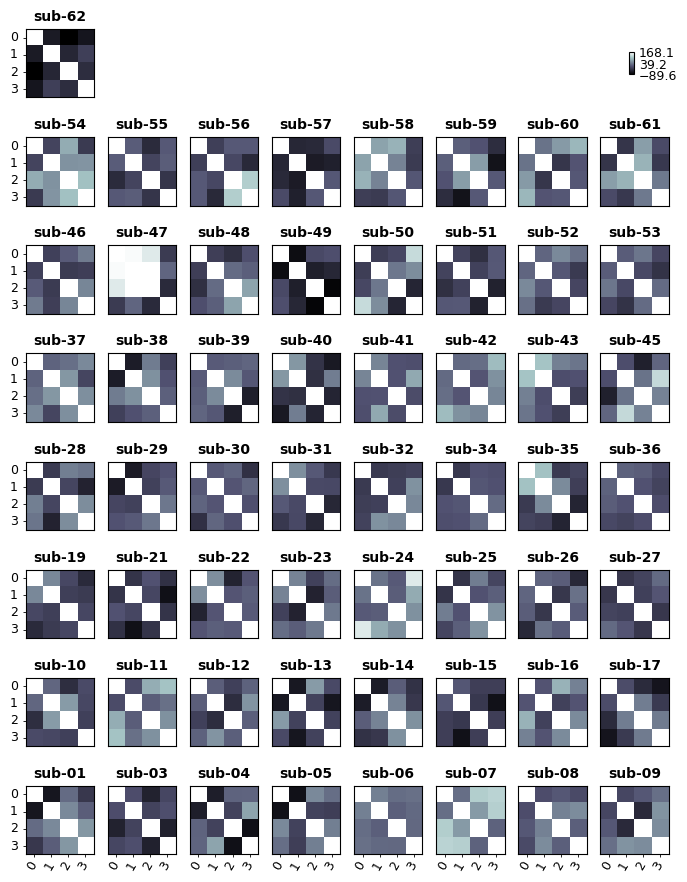

In [9]:
from  rsatoolbox import vis
vis.show_rdm(rdms, rdm_descriptor='subj', show_colorbar='figure', pattern_descriptor='index')

plt.show()

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

partial rsa pval: Entorhinal-right affordance 0.013010800419751539
TtestResult(statistic=2.286605893694301, pvalue=0.013010800419751539, df=56)
corr and pval: Entorhinal-right affordance 0.06152923793224144 0.6493429402827371


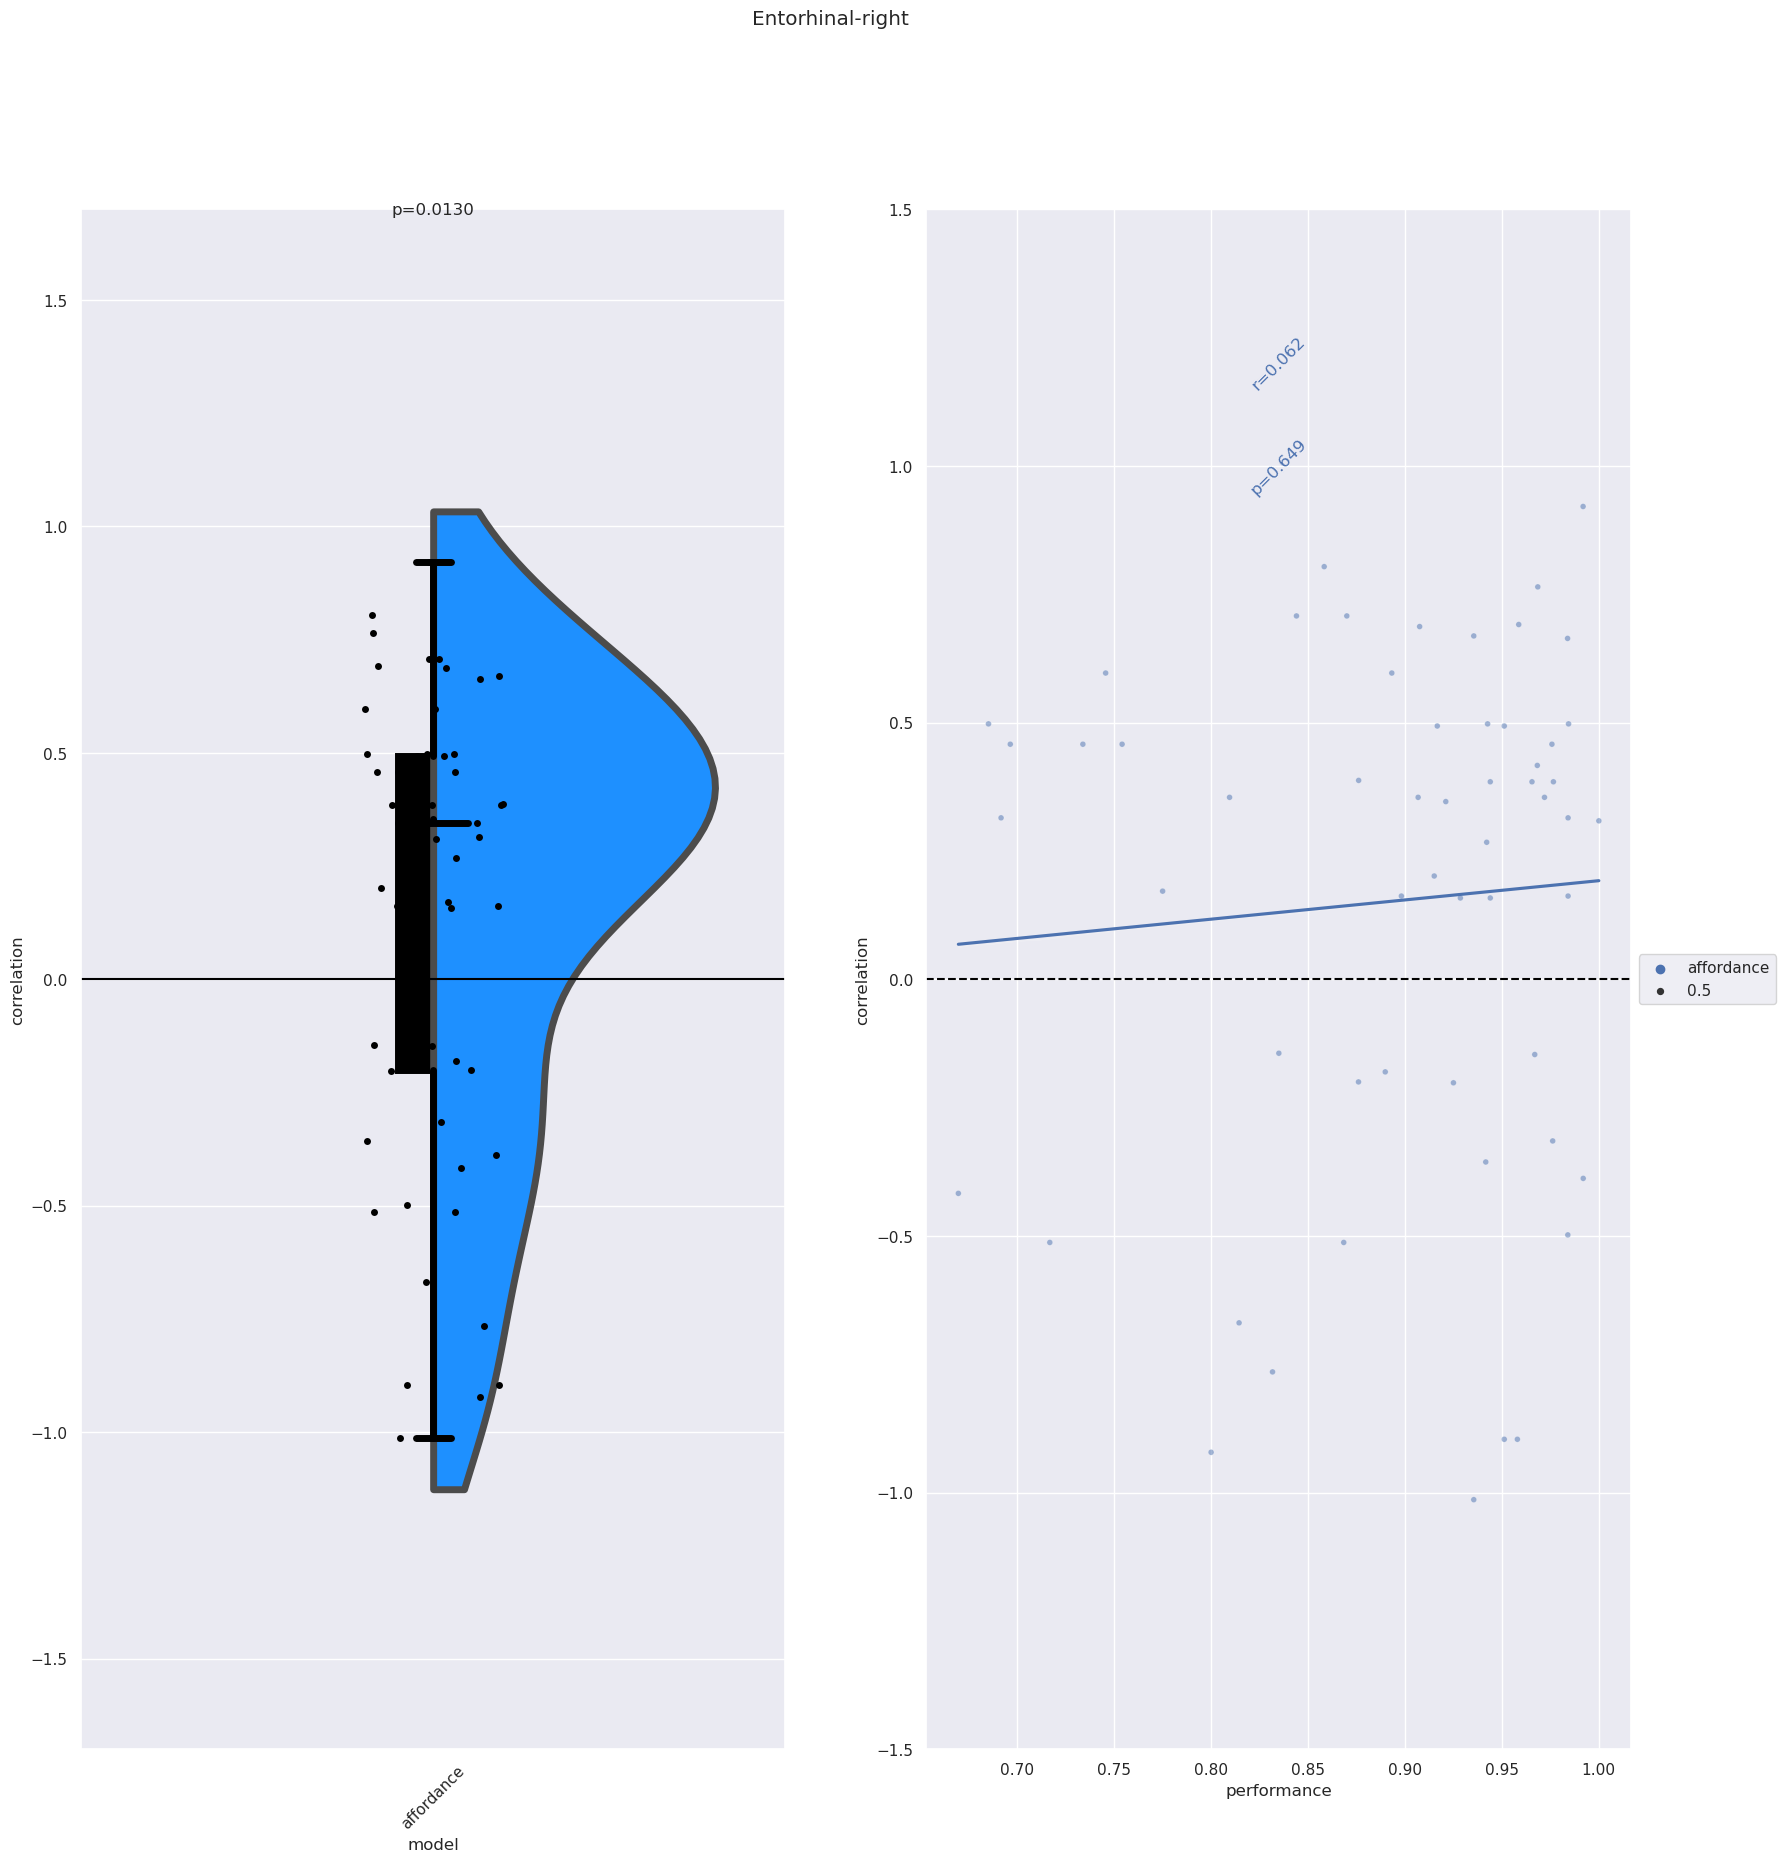

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

partial rsa pval: Entorhinal-left affordance 0.7261700089630452
TtestResult(statistic=-0.6049437372324569, pvalue=0.7261700089630452, df=56)
corr and pval: Entorhinal-left affordance -0.16581263486156758 0.21769606407189945


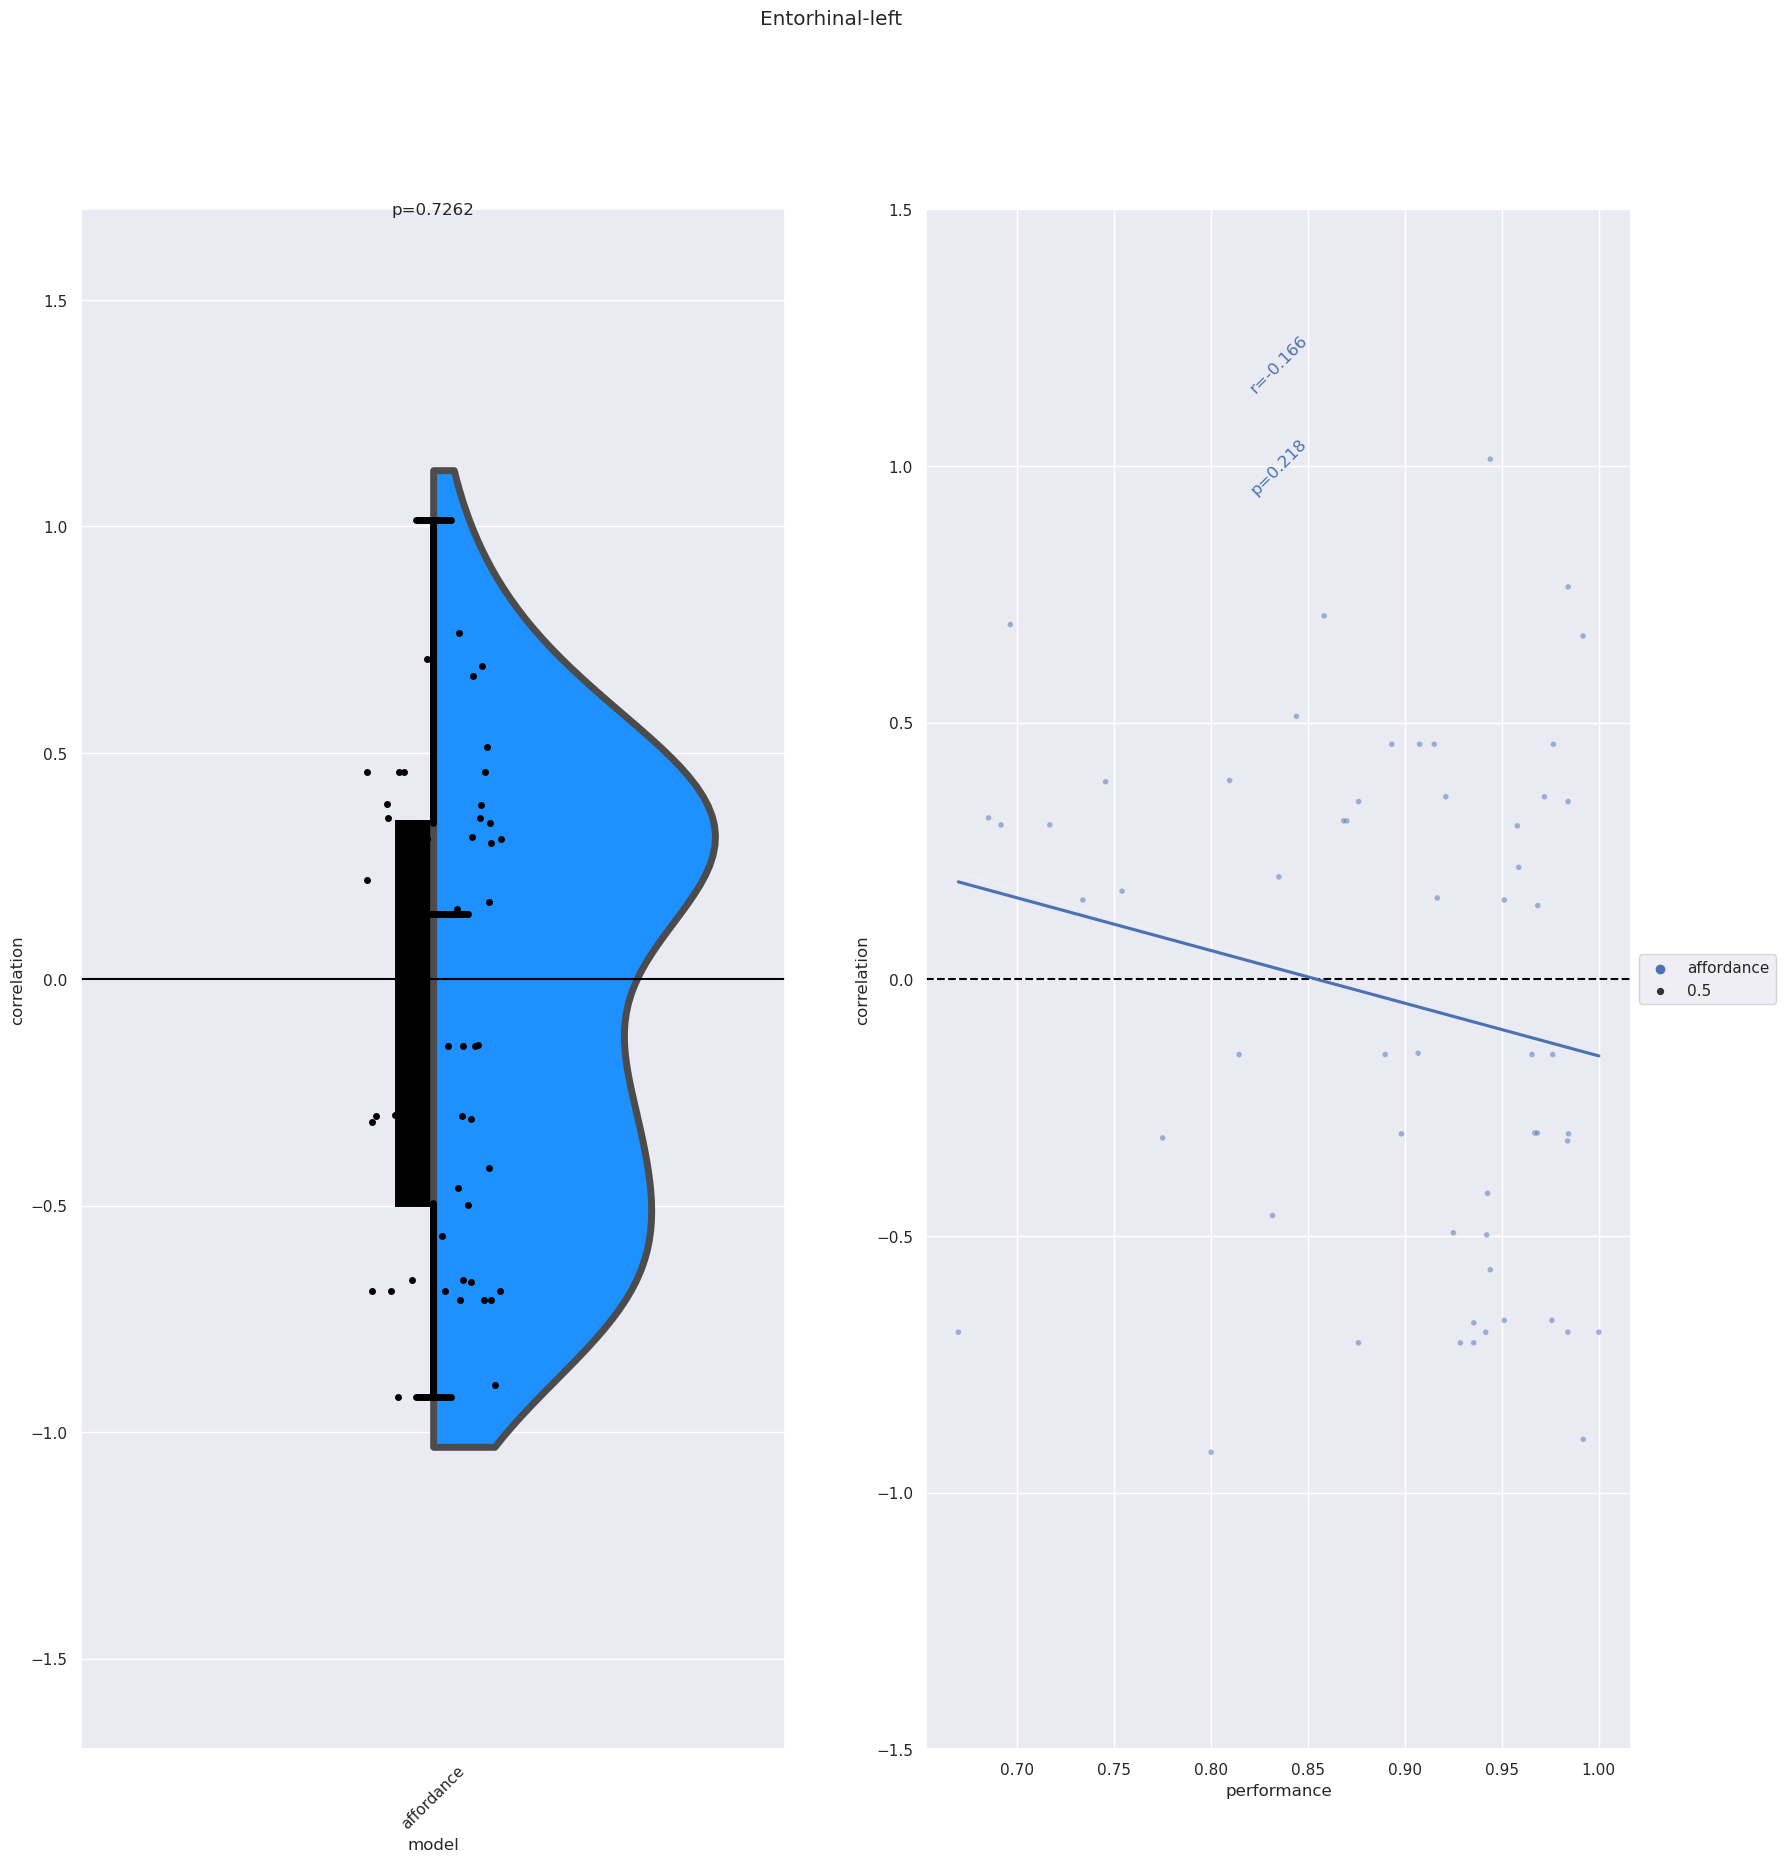

In [25]:

# for each region:

# set sns style to standard
sns.set(style='darkgrid')

# plot violinplot, x = model, y = correlation

# plot scatterplot, x = performance, y = correlation

for region_ in regions:
    region_data = df[df['region'] == region_]

    # exclude -inf and inf values for plotting
    #region_data_plot = region_data[~region_data.isin([np.inf, -np.inf]).any(1)]

    region_data_plot = region_data
    # cut amount is 1-max of correlation
    cut_amount = 1 - np.max(np.abs(region_data['correlation']))
    #print(cut_amount)

    fig, ax = plt.subplots(1, 2, figsize=(20, 20))
    
    # new region data df with no points > 1.5
    #region_data_plot = region_data[region_data['correlation'] < 1.5]
    ax_ = sns.violinplot(x='model', y='correlation', data=region_data_plot, ax=ax[0], cut=0.5,
                   hue=True, hue_order=[False, True], split=True, positions =5.5, native_scale=True, linewidth=5,
                     palette=sns.color_palette()[:len(models)]) 
    

    from matplotlib import pyplot as plt
    from matplotlib.colors import to_rgb
    from matplotlib.collections import PolyCollection
    colors = ['dodgerblue', 'lime', 'c', 'gray']
    handles = []
    for ind, violin in enumerate(ax_.findobj(PolyCollection)):
        rgb = to_rgb(colors[ind])
        violin.set_facecolor(rgb)

    
    


    # add points to plot on left of violinplot

    sns.stripplot(x='model', y='correlation', data=region_data_plot, ax=ax[0], color='black', jitter=True, dodge=True)
                  # move points to left side of violinplot

    # add boxplot on left of violinplot

    sns.boxplot(x='model', y='correlation', data=region_data_plot, ax=ax[0], color='black', width=0.1, linewidth=5)

    # add a horizontal line at 0
    ax[0].axhline(0, color='black')

    # max and min are -1.2 and 1.2
    #ax[0].set_ylim(-np.sqrt((57-3) / 1.06) * np.arctanh(0.99), np.sqrt((57-3) / 1.06) * np.arctanh(0.99))
    ax[0].set_ylim(-1.7, 1.7)

    # annotate with p values for ttest >0 (one sample ttest)
    for i in range(len(models)): # only take first model as we only care ab
        p = ttest_1samp(region_data[region_data['model'] == models[i]]['correlation'], 0, alternative='greater')[1]
        ax[0].annotate(f"p={p:.4f}", xy=(i, 1.7), ha='center', va='center')
        # print region and pval
        print('partial rsa pval:', region_, models[i], p)
        print(ttest_1samp(region_data[region_data['model'] == models[i]]['correlation'], 0, alternative='greater'))

    # rortate x labels
    for tick in ax[0].get_xticklabels():
        tick.set_rotation(45)
    

    sns.scatterplot(x='performance', y='correlation', hue='model',data=region_data, ax=ax[1], alpha=0.5, size=0.5)
    # make dots a bit transparent and smaller
    ax[1].axhline(0, ls='--', color='black')
    ax[1].set_ylim(-1.5, 1.5)
    # add line of best fit for each model
    count_x = 1
    # len x is number of models
    len_x = len(models)

    # move scatter plot legend to rght of plot and rotate text by 45 degrees
    ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
    # get rid of legend in violinplot
    ax[0].legend().remove()

    
    plt.suptitle(region_)
    plt.show()

    # save
    fig.savefig(f'/data/pt_02747/action_hippo/figures/rdm_correlations_{region_}_subs-{len(subs)}{append_str}.png', dpi=300, bbox_inches='tight')

In [ ]:
# show correlation values whwere model=affordance and region=hOc1-bilateral
list(df[(df['model'] == 'affordance') & (df['region'] == 'hOc1-bilateral')]['correlation'])

In [ ]:
np.arctanh(0.99)

In [ ]:
# check difference between models using paired ttest for each region

from scipy.stats import ttest_rel

for region in df['region'].unique():
    print(region)
    print('')
    # get data for region
    region_data = df[df['region'] == region]

    # for each model, do a paired ttest with affordance
    for model in models:
        for model2 in models:
            # do ttest
            t, p = ttest_rel(region_data[region_data['model'] == model]['correlation'], region_data[region_data['model'] == model2]['correlation'])
            if p < 0.05:
                print(model, ' x ', model2)
                print(p)
    print('='*20)


In [ ]:
df.to_csv('/data/pt_02747/action_hippo/data/derivatives/second_level/rdm_correlations_partial.csv', index=False)